# Создание NLP-пайплайна для обработки текстовых данных

Цель работы: Разработать модульный, воспроизводимый конвейер (пайплайн) предобработки текста на Python, который очищает сырой текст, приводит его к нормальной форме и готовит для дальнейшего анализа.

In [1]:
# Отображение графиков внутри ноутбука
%matplotlib inline

import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pymorphy3

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### Загрузка данных NLTK (выполнить один раз)

In [2]:
# Загрузка необходимых данных NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/kovs/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/kovs/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/kovs/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kovs/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Создание класса TextPreprocessor

Класс для предобработки текстов:
- очистки шума
- токенизации
- лемматизации (pymorphy3 для русского)
- удаления стоп-слов

In [3]:
class TextPreprocessor:

    def __init__(self, language='ru', remove_stopwords=True, use_lemmatization=True):
        """ Конструктор класса
        Args:
            language: 'ru' или 'en'
            remove_stopwords: удалять ли стоп-слова
            use_lemmatization: использовать ли лемматизацию
        """
        self.language = language
        self.remove_stopwords = remove_stopwords
        self.use_lemmatization = use_lemmatization

        # стоп-слова
        if language == 'ru':
            self.stop_words = set(stopwords.words('russian'))

            self.stop_words.update(['это', 'который', 'такой', 'весь', 'наш', 'ваш', 'ихний'])
            self.morph = pymorphy3.MorphAnalyzer()
        else:
            self.stop_words = set(stopwords.words('english'))
            self.lemmatizer = WordNetLemmatizer()

        print(f"TextPreprocessor: язык={language}, "
              f"remove_stopwords={remove_stopwords}, use_lemmatization={use_lemmatization}")

    def _clean_text(self, raw_text: str) -> str:
        """ Очистка текста от шума через регулярки
        Args:
            raw_text: исходный текст

        Returns:
            очищенный текст
        """
        if not isinstance(raw_text, str):
            return ""

        # приведение к нижнему регистру
        text = raw_text.lower()
        # удаление URL
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # удаление HTML-тегов
        text = re.sub(r'<[^>]+>', '', text)
        # удаление email-адресов
        text = re.sub(r'\S+@\S+', '', text)
        # удаление упоминаний пользователей (@username)
        text = re.sub(r'@\w+', '', text)
        # удаление хэштегов (оставляем только слово)
        text = re.sub(r'#', '', text)
        # удаление чисел
        text = re.sub(r'\d+', '', text)
        # удаление спецсимволов и пунктуации
        if self.language == 'ru':
            text = re.sub(r'[^а-яА-ЯёЁa-zA-Z\s]', ' ', text)
        else:
            text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        # замена множественных пробелов на один
        text = re.sub(r'\s+', ' ', text)
        # удаление начальных и конечных пробелов
        text = text.strip()

        return text

    def _lemmatize_russian(self, token: str) -> str:
        """Лемматизация русского слова с помощью pymorphy3"""
        parsed = self.morph.parse(token)[0]
        return parsed.normal_form

    def _lemmatize_english(self, token: str) -> str:
        """Лемматизация английского слова с помощью NLTK"""
        return self.lemmatizer.lemmatize(token)

    def process(self, text: str) -> list:
        """ Полная обработка текста
        Args:
            text: исходный текст
        Returns:
            список токенов
        """
        # очистка текста
        cleaned_text = self._clean_text(text)
        if not cleaned_text:
            return []

        # токенизация
        tokens = word_tokenize(cleaned_text, language='russian' if self.language == 'ru' else 'english')

        # фильтрация и нормализация
        processed_tokens = []

        for token in tokens:
            # пропуск коротких токенов
            if len(token) < 2:
                continue

            # удаление стоп-слов
            if self.remove_stopwords and token.lower() in self.stop_words:
                continue

            # лемматизация
            if self.use_lemmatization:
                if self.language == 'ru':
                    token = self._lemmatize_russian(token)
                else:
                    token = self._lemmatize_english(token)

            processed_tokens.append(token)

        return processed_tokens

## Функции визуализации

- Гистограмм распределения длины текстов
- Облака слов
- Топ-20 частотных слов

In [4]:
def pipeline(texts: list, processor: TextPreprocessor) -> pd.DataFrame:
    """ Конвейер обработки текстов
    Args:
        texts: список исходных текстов
        processor: экземпляр TextPreprocessor
    Returns:
        DataFrame с колонками raw_text, clean_text, tokens
    """
    results = []

    print(f"\nОбработка {len(texts)} текстов")

    for text in tqdm(texts, desc="Processing"):
        # очистка текста без токенизации
        clean_text = processor._clean_text(text)

        # обработка с токенизацией
        tokens = processor.process(text)

        results.append({
            'raw_text': text,
            'clean_text': clean_text,
            'tokens': tokens,
            'processed_text': ' '.join(tokens)
        })

    return pd.DataFrame(results)


def plot_length_distribution(df: pd.DataFrame):
    """Построение гистограмм распределения длины текстов"""

    # подсчет длин
    df['raw_length'] = df['raw_text'].str.len()
    df['clean_length'] = df['clean_text'].str.len()
    df['tokens_count'] = df['tokens'].apply(len)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # длина исходных текстов
    axes[0].hist(df['raw_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Количество символов')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение длины исходных текстов')
    axes[0].grid(True, alpha=0.3)

    # длина очищенных текстов
    axes[1].hist(df['clean_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Количество символов')
    axes[1].set_ylabel('Частота')
    axes[1].set_title('Распределение длины очищенных текстов')
    axes[1].grid(True, alpha=0.3)

    # количество токенов
    axes[2].hist(df['tokens_count'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Количество токенов')
    axes[2].set_ylabel('Частота')
    axes[2].set_title('Распределение количества токенов')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # статистика
    print(f"Средняя длина исходного текста: {df['raw_length'].mean():.2f} символов")
    print(f"Средняя длина очищенного текста: {df['clean_length'].mean():.2f} символов")
    print(f"Среднее количество токенов: {df['tokens_count'].mean():.2f}")
    print(f"Сжатие: {(1 - df['clean_length'].mean() / df['raw_length'].mean()) * 100:.2f}%")


def generate_wordcloud(df: pd.DataFrame):
    """Облака слов"""

    # объединение всех токенов в один текст
    all_tokens = []
    for tokens in df['tokens']:
        all_tokens.extend(tokens)

    text = ' '.join(all_tokens)

    # создание облака слов
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        max_words=200,
        colormap='viridis',
        relative_scaling=0.5
    ).generate(text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Облако слов (лемматизированные токены без стоп-слов)', fontsize=16)
    plt.tight_layout()
    plt.show()


def plot_top_words(df: pd.DataFrame, top_n: int = 20):
    """Построение графика топ-N частотных слов"""

    # подсчет частоты слов
    all_tokens = []
    for tokens in df['tokens']:
        all_tokens.extend(tokens)

    word_freq = Counter(all_tokens)
    most_common = word_freq.most_common(top_n)

    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]

    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(words)), counts, color='steelblue')
    plt.yticks(range(len(words)), words)
    plt.xlabel('Частота')
    plt.ylabel('Слова')
    plt.title(f'Топ-{top_n} частотных слов', fontsize=14)
    plt.gca().invert_yaxis()

    # добавление значений на столбцы
    for i, (bar, count) in enumerate(zip(bars, counts)):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return most_common

## 4. Загрузка датасета

Загружаем датасет отзывов с Кинопоиска с Hugging Face.

In [5]:
print("Загрузка датасета...")

splits = {
    'train': 'data/train-00000-of-00001.parquet',
    'test': 'data/test-00000-of-00001.parquet'
}

try:
    df = pd.read_parquet("hf://datasets/zloelias/kinopoisk-reviews-short/" + splits["train"])
    print(f"Загружено {len(df)} записей")
except Exception as e:
    print(f"Ошибка загрузки: {e}")
    print("Создаем тестовый датасет...")
    # Тестовые данные на случай проблем с загрузкой
    test_data = [
        "Отличный фильм! Сюжет захватывающий, актеры играют превосходно.",
        "Ужасно, не рекомендую. Потратил время зря.",
        "Нормальный фильм, посмотреть можно, но не шедевр.",
        "Лучший фильм года! Обязательно к просмотру!!!",
        "Средненько... Ожидал большего от этого режиссера.",
    ]
    df = pd.DataFrame({'text': test_data * 100})
    print(f"Создано {len(df)} тестовых записей")

# Определяем колонку с текстом
text_column = 'text' if 'text' in df.columns else df.columns[0]
print(f"Используется колонка: '{text_column}'")

# Показываем первые 3 записи
print("\nПервые 3 записи:")
for i, text in enumerate(df[text_column].head(3), 1):
    print(f"{i}. {text[:100]}...")

Загрузка датасета...


/home/kovs/Work/ML/nlp-labs/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружено 295 записей
Используется колонка: 'text'

Первые 3 записи:
1. Фильм ориентирован на маленьких детей не старше 10 лет. Смешного в фильме совсем мало. В графе жанр ...
2. Фильм может и классный, но для маленьких школьниц, парням там делать нечего. Типичный фильм для деву...
3. Идея фильма не оригинальна. Сюжет второсортный. Смотреть скучно, т.к. не очень уж интересно узнать, ...


## 5. EDA - Исследовательский анализ данных

Изучаем сырые данные перед обработкой.

In [6]:
# 10 случайных отзывов
print("\n10 случайных отзывов:")
sample_texts = df[text_column].sample(10, random_state=42).values
for i, text in enumerate(sample_texts, 1):
    print(f"{i:2d}. {text[:100]}...")

# статистика
total_chars = df[text_column].str.len().sum()
approx_words = df[text_column].str.split().str.len().sum()

print(f"Количество записей: {len(df)}")
print(f"Общее количество символов: {total_chars:,}")
print(f"Примерное количество слов: {approx_words:,}")

# проверка на шум (URL, HTML и тд)
has_urls = df[text_column].str.contains(r'http|www', na=False).sum()
has_html = df[text_column].str.contains(r'<[^>]+>', na=False).sum()

print(f"Записи с URL: {has_urls}")
print(f"Записи с HTML-тегами: {has_html}")

if has_urls == 0 and has_html == 0:
    print("Данные чистые, явного мусора не обнаружено")


10 случайных отзывов:
 1. Обожаю этот фильм. Полежит регулярному пересмотру для поднятия настроения и отрыва от реальности. Ве...
 2. Потрясающий фильм! Невозможно сказать чем. Вроде бы история простая до банальности и сюжет предсказу...
 3. Неплохой фильм с таким небольшим бюджетом. Довольно интересный, есть несколько резких моментов, чтоб...
 4. Отличный фильм!
В нём есть изрядная доля юмора и элементы экшена. Одним словом, позитивный заряд, по...
 5. Как грустно, что фильм даже не отбил свой бюджет. По-настоящему стильный и незанудный мистический фи...
 6. Абсолютно не понравился. Фильм о великовозрастных жеребцах-халявщиках. Так же на халяву они понаходи...
 7. Этот фильм можно транслировать как радиоспектакль. Тексты - это хорошо. Но плохие тексты это плохо. ...
 8. Милый, забавный, смешной, немножечко глупый фильм. Его хочется смотреть снова и снова. Замечательные...
 9. Все вторично и  предсказуемо. Рекомендовано к просмотру узкоспециализированным любителям вампиров....
10. Пре

## 6. Запуск пайплайна обработки

In [7]:
print("Создание и запуск пайплайна обработки...\n")

processor = TextPreprocessor(
    language='ru',
    remove_stopwords=True,
    use_lemmatization=True
)

# выбираем подмножество данных
sample_size = min(1000, len(df))
texts = df[text_column].head(sample_size).tolist()

print(f"\nБудет обработано {len(texts)} текстов")

# запуск
result_df = pipeline(texts, processor)

print(f"\nРезультат: {len(result_df)} записей")

print("\nПервые 3 записи:")
for i, (idx, row) in enumerate(result_df.head(3).iterrows(), 1):
    print(f"\nЗапись {i}:")
    print(f"Исходный: {row['raw_text'][:80]}...")
    print(f"Токены ({len(row['tokens'])}): {', '.join(row['tokens'][:8])}{'...' if len(row['tokens']) > 8 else ''}")
    print(f"Итоговый: {row['processed_text'][:80]}...")

Создание и запуск пайплайна обработки...

TextPreprocessor: язык=ru, remove_stopwords=True, use_lemmatization=True

Будет обработано 295 текстов

Обработка 295 текстов


Processing: 100%|██████████| 295/295 [00:00<00:00, 814.05it/s]


Результат: 295 записей

Первые 3 записи:

Запись 1:
Исходный: Фильм ориентирован на маленьких детей не старше 10 лет. Смешного в фильме совсем...
Токены (23): фильм, ориентировать, маленький, ребёнок, старший, год, смешной, фильм...
Итоговый: фильм ориентировать маленький ребёнок старший год смешной фильм мало граф жанр н...

Запись 2:
Исходный: Фильм может и классный, но для маленьких школьниц, парням там делать нечего. Тип...
Токены (17): фильм, классный, маленький, школьница, парень, делать, нечего, типичный...
Итоговый: фильм классный маленький школьница парень делать нечего типичный фильм девушка к...

Запись 3:
Исходный: Идея фильма не оригинальна. Сюжет второсортный. Смотреть скучно, т.к. не очень у...
Токены (22): идея, фильм, оригинальный, сюжет, второсортный, смотреть, скучно, очень...
Итоговый: идея фильм оригинальный сюжет второсортный смотреть скучно очень интересно узнат...


## 7. Визуализация результатов

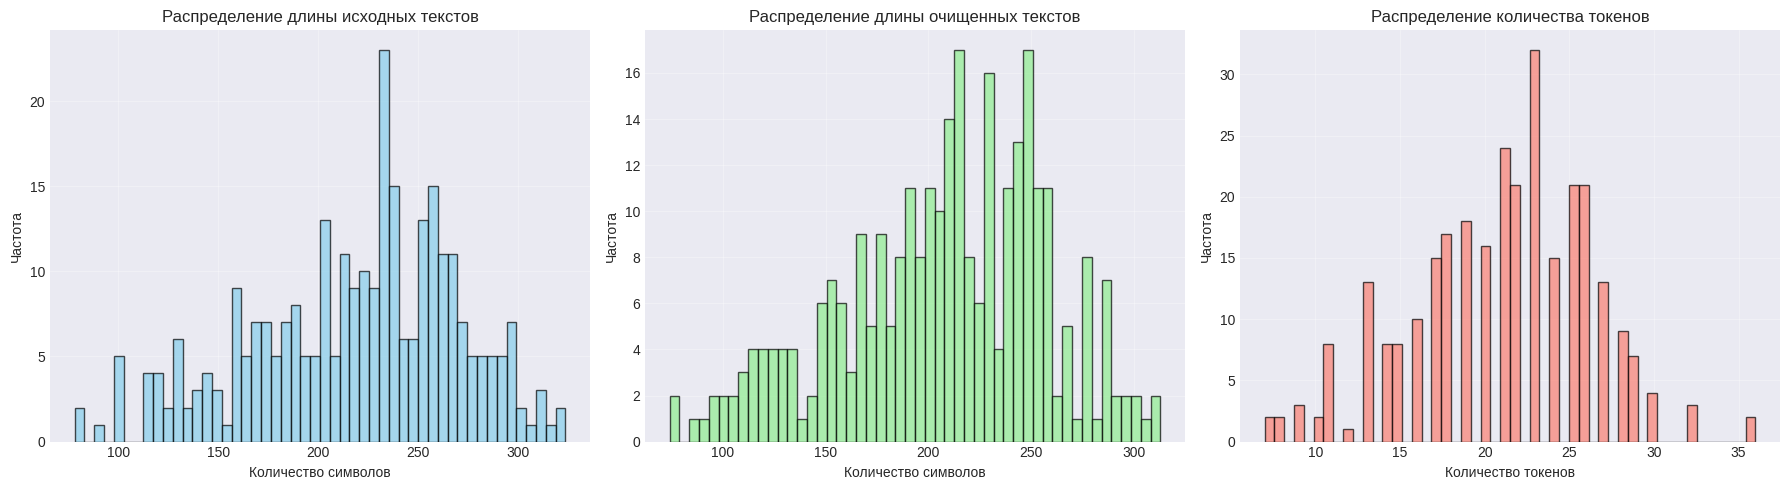

Средняя длина исходного текста: 218.62 символов
Средняя длина очищенного текста: 207.24 символов
Среднее количество токенов: 20.98
Сжатие: 5.20%


In [8]:
plot_length_distribution(result_df)

### 7.2 Облако слов

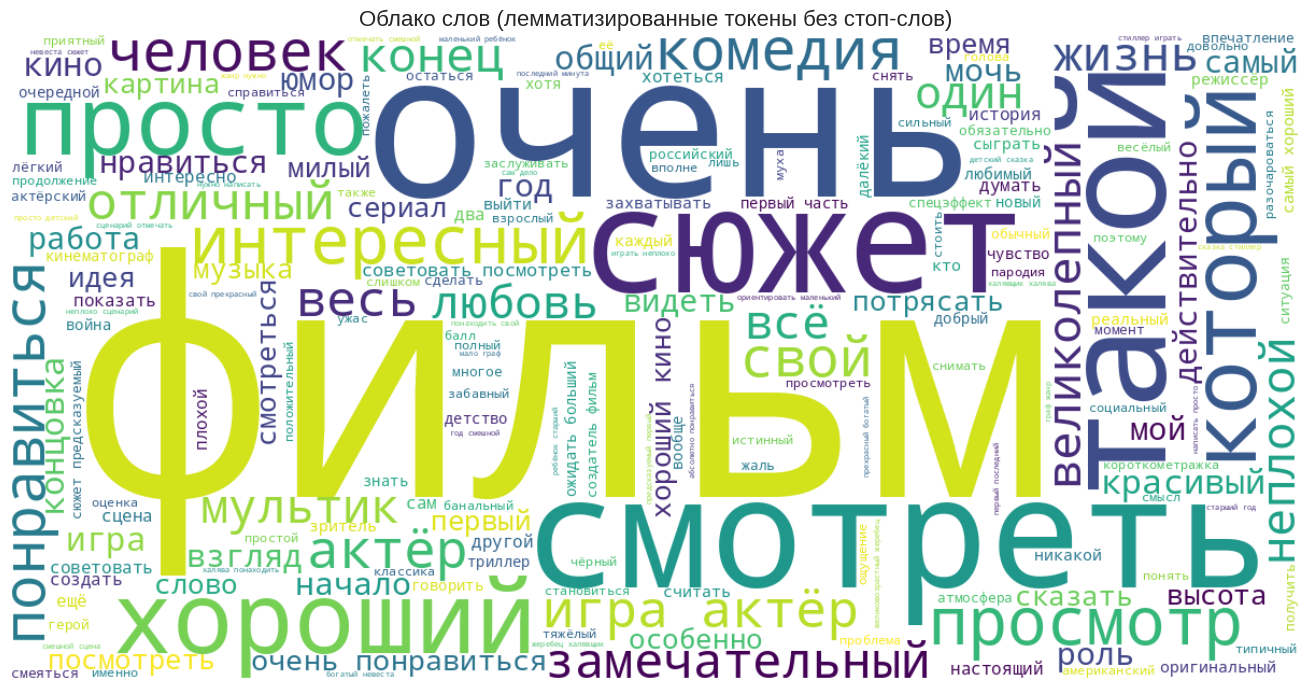

In [9]:
generate_wordcloud(result_df)

### 7.3 Топ-20 частотных слов

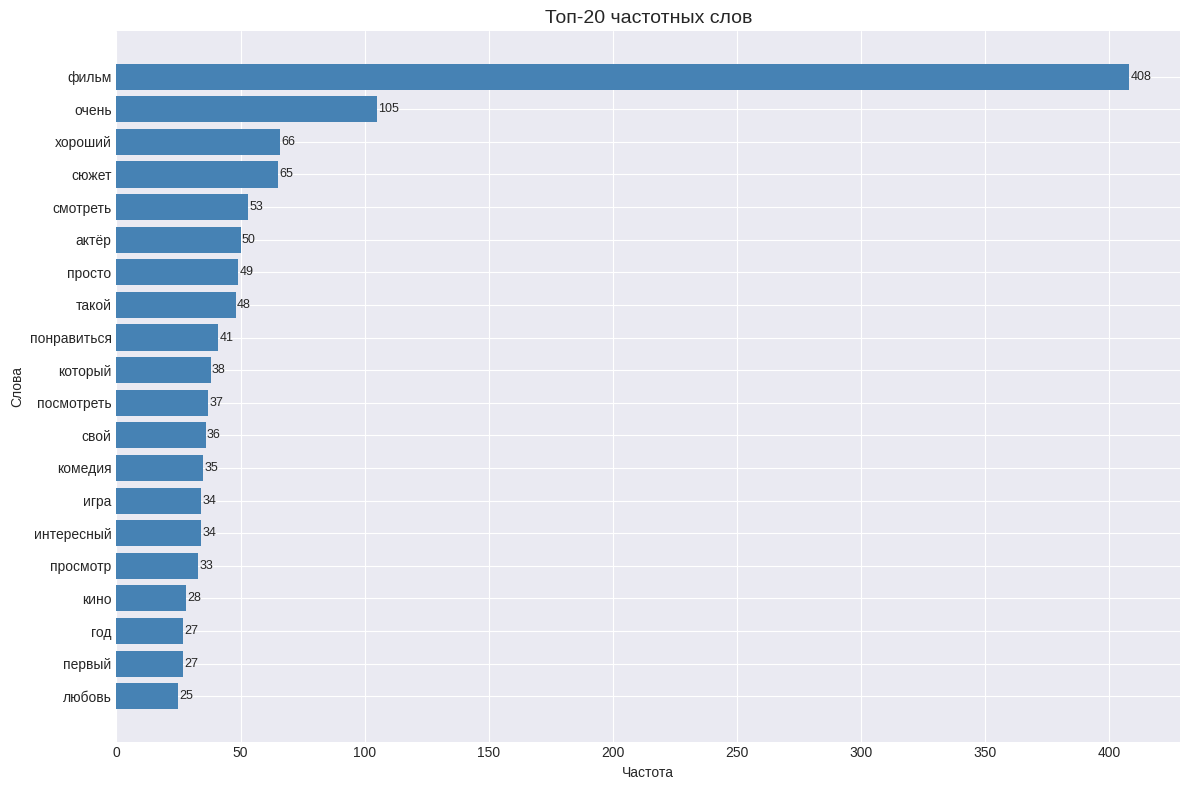


Топ-20 частотных слов:
 1. фильм           (408 раз)
 2. очень           (105 раз)
 3. хороший         ( 66 раз)
 4. сюжет           ( 65 раз)
 5. смотреть        ( 53 раз)
 6. актёр           ( 50 раз)
 7. просто          ( 49 раз)
 8. такой           ( 48 раз)
 9. понравиться     ( 41 раз)
10. который         ( 38 раз)
11. посмотреть      ( 37 раз)
12. свой            ( 36 раз)
13. комедия         ( 35 раз)
14. игра            ( 34 раз)
15. интересный      ( 34 раз)
16. просмотр        ( 33 раз)
17. кино            ( 28 раз)
18. год             ( 27 раз)
19. первый          ( 27 раз)
20. любовь          ( 25 раз)


In [10]:
top_words = plot_top_words(result_df, top_n=20)

print("\nТоп-20 частотных слов:")
for i, (word, count) in enumerate(top_words, 1):
    print(f"{i:2d}. {word:<15} ({count:>3} раз)")

## 8. Сохранение результатов

In [11]:
# сохранение в CSV
output_file = 'processed_reviews.csv'
result_df.to_csv(output_file, index=False, encoding='utf-8')
print(f"Результаты сохранены в: {output_file}")

# информация о файле
import os
file_size = os.path.getsize(output_file) / 1024
print(f"Размер файла: {file_size:.2f} KB")

# показываем структуру DataFrame
print(f"\nСтруктура результирующего DataFrame:")
print(result_df.info())

Результаты сохранены в: processed_reviews.csv
Размер файла: 430.76 KB

Структура результирующего DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   raw_text        295 non-null    str   
 1   clean_text      295 non-null    str   
 2   tokens          295 non-null    object
 3   processed_text  295 non-null    str   
 4   raw_length      295 non-null    int64 
 5   clean_length    295 non-null    int64 
 6   tokens_count    295 non-null    int64 
dtypes: int64(3), object(1), str(3)
memory usage: 332.0+ KB
None
